In [1]:
import pandas as pd
import pickle

In [2]:
with open("/content/x_train_processed.pkl", "rb") as f:
    x_train_processed = pickle.load(f)

with open("/content/x_test_processed.pkl", "rb") as f:
    x_test_processed = pickle.load(f)

with open("/content/y_train.pkl", "rb") as f:
    y_train = pickle.load(f)

with open("/content/y_test.pkl", "rb") as f:
    y_test = pickle.load(f)

In [3]:
print(x_train_processed.shape)
print(x_test_processed.shape)
print(y_train.shape)
print(y_test.shape)

(5634, 45)
(1409, 45)
(5634,)
(1409,)


In [4]:
from sklearn.linear_model import LogisticRegression

In [5]:
model = LogisticRegression(random_state=42)

In [6]:
model.fit(x_train_processed, y_train)

LogisticRegression(random_state=42)

In [7]:
y_pred = model.predict(x_test_processed)

In [8]:
y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [11]:
y_pred.shape

(1409,)

In [12]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8055358410220014


In [13]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.66      0.56      0.60       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[926 109]
 [165 209]]


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

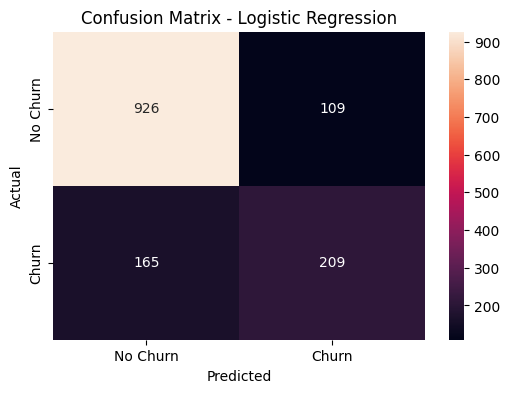

In [16]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["No Churn", "Churn"],
    yticklabels=["No Churn", "Churn"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

In [17]:
model.predict_proba(x_test_processed)

array([[0.95408007, 0.04591993],
       [0.31628655, 0.68371345],
       [0.94106015, 0.05893985],
       ...,
       [0.84557785, 0.15442215],
       [0.99571355, 0.00428645],
       [0.99371199, 0.00628801]])

In [21]:
y_prob = model.predict_proba(x_test_processed)[:, 1]
print(y_prob[:10])

[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [22]:
from sklearn.metrics import roc_auc_score

In [23]:
roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)

ROC-AUC: 0.8421349040274871


## Logistic Regression Baseline

The Logistic Regression model achieved approximately 81% accuracy
and a ROC-AUC score of 0.84 on the test set.

The model achieved 56% recall and 60% F1-score for churned customers.
This indicates that the model can distinguish between churners and
non-churners reasonably well, but it misses a significant proportion
of actual churners at the default classification threshold.

Therefore, additional models and threshold tuning will be explored
to improve churn detection.

In [25]:
from sklearn.ensemble import RandomForestClassifier

In [26]:
rf_model=RandomForestClassifier(random_state=42,n_estimators=200)

In [27]:
rf_model.fit(x_train_processed,y_train)

RandomForestClassifier(n_estimators=200, random_state=42)

In [29]:
rf_y_pred=rf_model.predict(x_test_processed)
rf_y_pred

array([0, 1, 0, ..., 0, 0, 0])

In [33]:
from sklearn.metrics import accuracy_score
rf_accuracy=accuracy_score(y_test,rf_y_pred)
print("Accuracy:",rf_accuracy)

Accuracy: 0.7877927608232789


In [35]:
from sklearn.metrics import classification_report
print(classification_report(y_test,rf_y_pred))


              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.49      0.55       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [36]:
rf_y_prob = rf_model.predict_proba(x_test_processed)[:, 1]

print(rf_y_prob[:10])

[0.    0.68  0.055 0.31  0.01  0.36  0.375 0.07  0.    0.46 ]


In [37]:
from sklearn.metrics import roc_auc_score

rf_roc_auc = roc_auc_score(y_test, rf_y_prob)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.8174765558397272


In [38]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [accuracy, rf_accuracy],
    "ROC-AUC": [roc_auc, rf_roc_auc]
})

comparison

,Model,Accuracy,ROC-AUC
0,Logistic Regression,0.805536,0.842135
1,Random Forest,0.787793,0.817477


In [39]:
y_prob = model.predict_proba(x_test_processed)[:, 1]

print(y_prob[:10])

[0.04591993 0.68371345 0.05893985 0.40183529 0.02142426 0.60297803
 0.44762898 0.13033554 0.00280355 0.39473874]


In [40]:
threshold = 0.4

y_pred_04 = (y_prob >= threshold).astype(int)

print(y_pred_04[:10])

[0 1 0 1 0 1 1 0 0 0]


In [41]:
accuracy_04 = accuracy_score(y_test, y_pred_04)

print("Accuracy with threshold 0.4:", accuracy_04)

Accuracy with threshold 0.4: 0.7771469127040455


In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_04))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.67      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(
        "Threshold:", threshold,
        "Accuracy:", round(accuracy, 2),
        "Precision:", round(precision, 2),
        "Recall:", round(recall, 2),
        "F1:", round(f1, 2)
    )

Threshold: 0.3 Accuracy: 0.75 Precision: 0.52 Recall: 0.75 F1: 0.62
Threshold: 0.4 Accuracy: 0.78 Precision: 0.57 Recall: 0.67 F1: 0.61
Threshold: 0.5 Accuracy: 0.81 Precision: 0.66 Recall: 0.56 F1: 0.6
Threshold: 0.6 Accuracy: 0.8 Precision: 0.72 Recall: 0.4 F1: 0.51
Threshold: 0.7 Accuracy: 0.77 Precision: 0.74 Recall: 0.18 F1: 0.3


In [44]:
thresholds = [0.3, 0.4, 0.5, 0.6, 0.7]

precisions = []
recalls = []
f1_scores = []

for threshold in thresholds:
    y_pred = (y_prob >= threshold).astype(int)

    precisions.append(precision_score(y_test, y_pred))
    recalls.append(recall_score(y_test, y_pred))
    f1_scores.append(f1_score(y_test, y_pred))

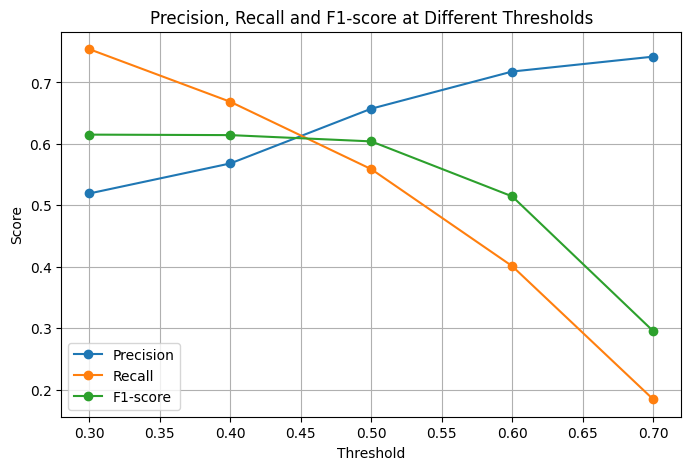

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(thresholds, precisions, marker="o", label="Precision")
plt.plot(thresholds, recalls, marker="o", label="Recall")
plt.plot(thresholds, f1_scores, marker="o", label="F1-score")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall and F1-score at Different Thresholds")
plt.legend()
plt.grid()
plt.show()

In [46]:
best_threshold = 0.3

final_y_pred = (y_prob >= best_threshold).astype(int)

print("Selected Threshold:", best_threshold)

Selected Threshold: 0.3


In [48]:
import pickle

with open("/content/logistic_regression_model.pkl", "wb") as f:
    pickle.dump(model, f)